# Practical Machine Learning for Physicists
# Coursework D

In this notebook you will be trying to predict a system using incomplete information. We will set up the equations of motions for a simple double pendulum (or should that be a double simple pendulum. Then we will see if a machine learning technique can predict the future position of the lower mass, using only the lower mass positions.

### Kinematics of the double pendulum
Let's specify our problem in terms of the following, with the origin at the pivot point of the top pendulum. This is just background for the machine learning tasks at the bottom of the notebook.

#### Positions
$$x_1 = L_1 \sin \theta_1$$
$$y_1 = -L_1 \cos \theta_1$$
$$x_2 = x_1 + L_2 \sin \theta_2$$
$$y_2 = y_1 - L_2 \cos \theta_2$$

#### Velocities
$$\dot{x}_1 = \dot{\theta_1} L_1 \cos \theta_1$$
$$\dot{y_1} =  \dot{\theta_1} L_1 \sin \theta_1$$
$$\dot{x_2} = \dot{x_1} + \dot{\theta_2} L_2 \cos \theta_2$$
$$\dot{y_2} = \dot{y_1} + \dot{\theta_2} L_2 \sin \theta_2$$


#### Accelerations

$$\ddot{x}_1 = -\dot{\theta_1}^2 L_1 \sin \theta_1 + \ddot{\theta_1} L_1 \cos \theta_1$$
$$\ddot{y_1} =  \dot{\theta_1}^2 L_1 \cos \theta_1 + \ddot{\theta_1} L_1 \sin \theta_1$$
$$\ddot{x_2} = \ddot{x_1} - \dot{\theta_2}^2 L_2 \sin \theta_2 + \ddot{\theta_2} L_2 \cos \theta_2$$
$$\ddot{y_2} = \ddot{y_1} + \dot{\theta_2}^2 L_2 \cos \theta_2 + \ddot{\theta_2} L_2 \sin \theta_2$$

#### Energies
Let $v_1^2 = \dot{x_1}^2 +\dot{y_1}^2$ and $v_2^2 = \dot{x_2}^2 +\dot{y_2}^2$ then the kinetic energies $T_1$ and $T_2$ are
$$ T_1 = \frac{1}{2}m_1 v_1^2 = \frac{1}{2}m_1 L_1^2 \dot{\theta_1}^2 $$
$$ T_2 = \frac{1}{2}m_2 v_2^2 = \frac{1}{2}m_2 \left( L_1^2 \dot{\theta_1}^2 + L_2^2 \dot{\theta_2}^2 + 2L_1 L_2 \cos(\theta_1-\theta_2) \dot{\theta_1} \dot{\theta_2} \right) $$

The potential enrgies are
$$V_1 = m_1 g y_1 = - m_1 g L_1 \cos \theta_1$$
$$V_2 = m_2 g y_2 = -m_2 g ( L_1 \cos \theta_1 + L_2 \cos \theta_2)$$

#### Langrangian
Now we form the Lagrangian $L=T-V=T_1+T_2 -V_1 -V_2$ and use the Euler-Lagrange equations:
$$\frac{\partial L}{\partial \theta_1} = \frac{d}{dt}\frac{\partial L}{\partial \dot{\theta_1}}$$
$$\frac{\partial L}{\partial \theta_2} = \frac{d}{dt}\frac{\partial L}{\partial \dot{\theta_2}}$$

Applying these gives
$$-(m_1+m_2) g L_1 \sin \theta_1 = (m_1+m_2) L_1^2 \ddot{\theta_1} + m_2 L_1 L_2 \sin(\theta_1-\theta_2) \dot{\theta_2}^2 +  m_2 L_1 L_2 \cos(\theta_1-\theta_2) \ddot{\theta_2} $$
and
$$ -m_2 g L_2 \sin \theta_2 = m_2 L_2 \ddot{\theta_2} + m_2 L_1 L_2 \cos(\theta_1-\theta_2) \ddot{\theta_1} + m_2 L_1 L_2 \sin(\theta_1-\theta_2) \dot{\theta_1}^2 $$


#### Equations of motions
$$ \omega_1 = \dot{\theta_1}$$  

$$ \omega_2 = \dot{\theta_2}$$
$$ \ddot\theta_1 = \frac{1}{L_1\xi}\left[L_1m_2\cos(\theta_1-\theta_2)\sin(\theta_1-\theta_2)\omega_1^2 + L_2m_2\sin(\theta_1-\theta_2)\omega_2^2 - m_2g\cos(\theta_1-\theta_2)\sin(\theta_2) + (m_1+m_2)g\sin(\theta_1) \right] $$
$$ \ddot\theta_2 = \frac{1}{L_2\xi}\left[L_2m_2\cos(\theta_1-\theta_2)\sin(\theta_1-\theta_2)\omega_2^2 + L_1(m_1+m_2)\sin(\theta_1-\theta_2)\omega_1^2+(m_1+m_2)g\sin(\theta_1)\cos(\theta_1-\theta_2) - (m_1+m_2)g\sin(\theta_2) \right] $$
where
$$\xi \equiv \cos^2(\theta_1-\theta_2)m_2-m_1-m_2$$


In [66]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

import matplotlib.style #Some style nonsense
import matplotlib as mpl #Some more style nonsense

import tensorflow as tf
from tensorflow import keras

#Set default figure size
#mpl.rcParams['figure.figsize'] = [12.0, 8.0] #Inches... of course it is inches
mpl.rcParams["legend.frameon"] = False
mpl.rcParams['figure.dpi']=200 # dots per inch



In [67]:
def rhs(t, z, L1, L2, m1, m2, g):
    """
    Returns the right-hand side of the ordinary differential equation describing the double pendulem
    """
    theta1, w1, theta2, w2 = z    #The four components
    cos12 = np.cos(theta1 - theta2)
    sin12 = np.sin(theta1 - theta2)
    sin1 = np.sin(theta1)
    sin2 = np.sin(theta2)
    xi = cos12**2*m2 - m1 - m2
    w1dot = ( L1*m2*cos12*sin12*w1**2 + L2*m2*sin12*w2**2
            - m2*g*cos12*sin2      + (m1 + m2)*g*sin1)/(L1*xi)
    w2dot = -( L2*m2*cos12*sin12*w2**2 + L1*(m1 + m2)*sin12*w1**2
            + (m1 + m2)*g*sin1*cos12  - (m1 + m2)*g*sin2 )/(L2*xi)
    return w1, w1dot, w2, w2dot   #Return the w's and the wdot's


def to_cartesian(theta1, w1, theta2, w2, L1, L2):
    """ Transforms theta and omega to cartesian coordinates
    and velocities x1, y1, x2, y2, vx1, vy1, vx2, vy2
    """
    x1 = L1 * np.sin(theta1)
    y1 = -L1 * np.cos(theta1)
    x2 = x1 + L2 * np.sin(theta2)
    y2 = y1 - L2 * np.cos(theta2)
    vx1 = L1*np.cos(theta1)*w1
    vy1 = L1*np.sin(theta1)*w1
    vx2 = vx1 + L2*np.cos(theta2)*w2
    vy2 = vy1 + L2*np.sin(theta2)*w2
    return x1, y1, x2, y2, vx1, vy1, vx2, vy2


In [68]:
# Set up the initial conditions. Here we have lengths and masses
L1, L2 = 1., 1.
m1, m2 = 3., 1.
g = 9.81     # [m/s^2]. Gravitational acceleration

#Starting angles
z0=[np.pi/4,0,np.pi/4,0]
#z0=[0.1,0,0.1,0]

#Time ranges
tmax, dt = 50, 0.1
t = np.arange(0, tmax+dt, dt)

In [69]:
# Solve initial value problem
ret = solve_ivp(rhs, (0,tmax), z0, t_eval=t, args=(L1, L2, m1, m2, g))
z=ret.y
print(np.shape(z))

# Extract result
theta1, w1, theta2, w2 = z[0], z[1], z[2], z[3]
x1, y1, x2, y2, vx1, vy1, vx2, vy2 = to_cartesian(theta1, w1, theta2, w2, L1, L2)

(4, 501)


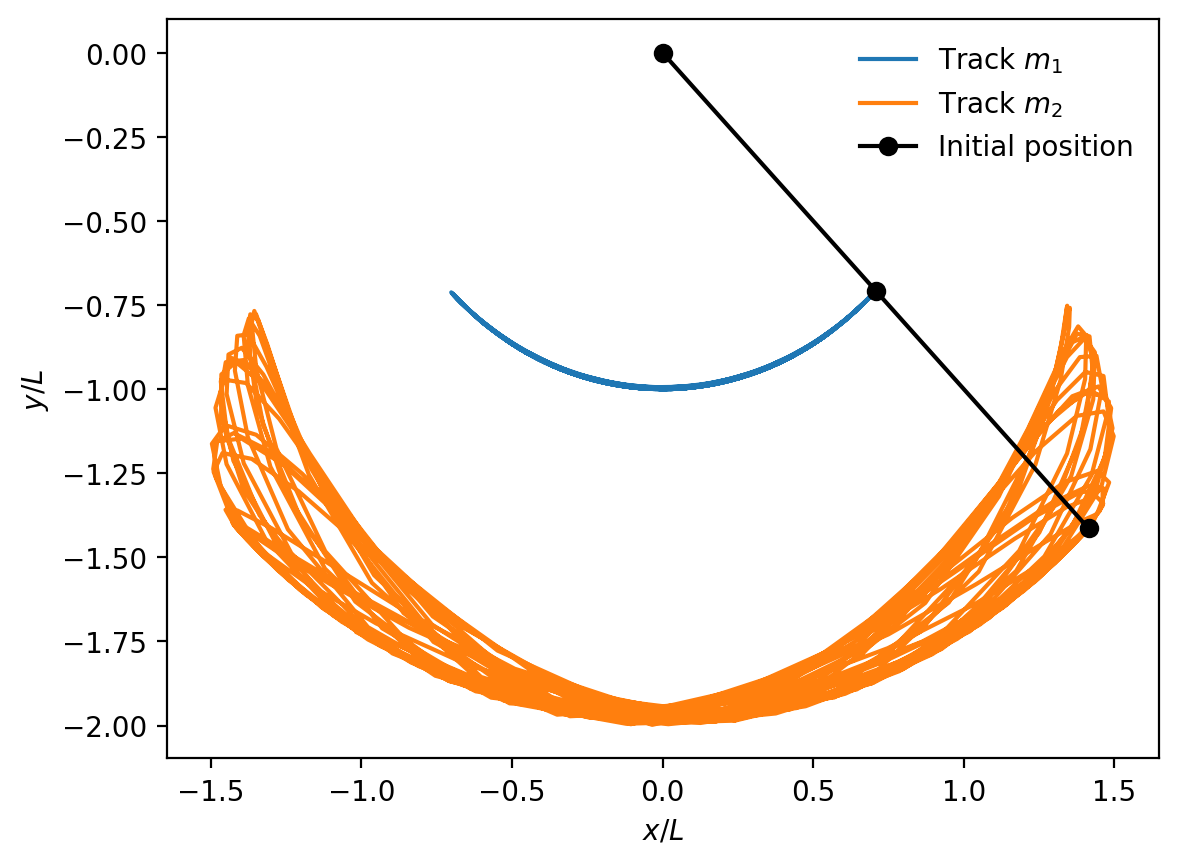

In [70]:
fig,ax=plt.subplots()
ax.plot(x1, y1, label=r"Track $m_1$")
ax.plot(x2, y2, label=r"Track $m_2$")
ax.plot([0, x1[0], x2[0]], [0, y1[0], y2[0]], "-o", label="Initial position", c='k')
plt.ylabel(r"$y/L$")
plt.xlabel(r"$x/L$")
ax.legend()

# Exercises: Predicting Chaos
1. Design and train a recurrent neural network (of your choice) to predict the future positions, where future is defined as $t=t_0 + 20 \delta t$, of the masses $m_1$ and $m_2$ using their cartesian coordinates and the initial conditions  $z_0=[\pi/4,0,\pi/4,0]$.
2. How stable is your network to variations in initial conditions? Make a plot of $x$ and $y$ vs time to show the network prediction in comparison to the solution from solve_ivp
3. How far into the future can a network predict? Make a plot showing how the deviation between predicted position and actual position (from solve_ivp above) vary as a function of extrapolation time from $t=t_0 + 20 \delta t$ to $t=t_0 + 100 \delta t$  (e.g. for each extrapolation time, train a new version of the network and then plot the performance)
4. Repeat steps 1-3 for the initial conditions $z_0=[\pi/2,0,\pi/2,0]$ which give a much more complex path.
5. Repeat steps 1-4 but only train your neural network on the cartesian coordinates of the mass $m_2$ (i.e without showing your neural network the positions of the mass $m_1$)



## Define Functions

In [71]:
# Global hyperparameters
WINDOW_SIZE  = 20     # steps of history fed as input
OFFSET       = 20     # default: predict 20 steps (2 s) ahead
EPOCHS       = 60
BATCH_SIZE   = 32
LSTM_UNITS   = 64

# Physics: generate a trajectory and return Cartesian data
def solve_pendulum(z0, tmax=50, dt=0.1):
    """
    Integrates the double pendulum ordinary differential equations (ODEs) to generate
    a simulated trajectory and converts the angular data into Cartesian coordinates.

    Args:
        z0 (list or array): Initial states [theta1, omega1, theta2, omega2].
        tmax (int or float, optional): Maximum simulation time in seconds. Defaults to 50.
        dt (float, optional): Time step for the integration. Defaults to 0.1.

    Returns:
        t_arr (numpy.ndarray): 1D array of evaluated time points of shape (N,).
        cart (numpy.ndarray): 2D array of Cartesian coordinates with columns [x1, y1, x2, y2] of shape (N, 4).
    """
    t_arr = np.arange(0, tmax + dt, dt)
    ret   = solve_ivp(rhs, (0, tmax), z0, t_eval=t_arr,
                      args=(L1, L2, m1, m2, g))
    th1, w1_, th2, w2_ = ret.y
    x1_, y1_, x2_, y2_, *_ = to_cartesian(th1, w1_, th2, w2_, L1, L2)
    return t_arr, np.column_stack([x1_, y1_, x2_, y2_])

# Data: normalisation and sliding windows
def normalise(data, mean=None, std=None):
    """
    Applies Z-score normalization to the dataset to ensure zero mean and unit variance.

    Args:
        data (numpy.ndarray): The raw numerical data to be normalized.
        mean (numpy.ndarray, optional): Pre-computed mean. If None, it is calculated from the data.
        std (numpy.ndarray, optional): Pre-computed standard deviation. If None, it is calculated.

    Returns:
        normalised_data (numpy.ndarray): The standardized data.
        mean (numpy.ndarray): The mean used for normalization (saved for later denormalization).
        std (numpy.ndarray): The standard deviation used for normalization.
    """
    if mean is None: mean = data.mean(axis=0)
    if std  is None:
        std = data.std(axis=0)
        std[std == 0] = 1.0
    return (data - mean) / std, mean, std

def denormalise(data_norm, mean, std):
  """
    Reverses the Z-score normalization to convert predictions back into physical units.

    Args:
        data_norm (numpy.ndarray): The normalized data output by the model.
        mean (numpy.ndarray): The original mean of the training dataset.
        std (numpy.ndarray): The original standard deviation of the training dataset.

    Returns:
        numpy.ndarray: The denormalized data in original physical scale.
    """
  return data_norm * std + mean

def make_windows(data, window_size, offset):
    """
    Slices the continuous time-series data into overlapping sliding windows for model training.

    Args:
        data (numpy.ndarray): The full sequential dataset of shape (N, features).
        window_size (int): The number of historical time steps used as input.
        offset (int): The number of time steps into the future to predict.

    Returns:
        X (numpy.ndarray): Input feature windows of shape (N_win, window_size, features).
        y (numpy.ndarray): Target prediction values of shape (N_win, features).
    """
    N = len(data)
    n_win = N - window_size - offset + 1
    X = np.array([data[i : i + window_size]          for i in range(n_win)])
    y = np.array([data[i + window_size + offset - 1] for i in range(n_win)])
    return X, y

# build model (parameterised by n_features)
def build_model(window_size, n_features, lstm_units=LSTM_UNITS):
    """
    Constructs and compiles a Keras Sequential neural network for time-series forecasting.

    Args:
        window_size (int): The length of the input history window.
        n_features (int): The number of features to predict (e.g., 4 for both masses, 2 for m2 only).
        lstm_units (int, optional): The number of neurons in the LSTM layer. Defaults to global LSTM_UNITS.

    Returns:
        model (keras.engine.sequential.Sequential): A compiled Keras model ready for training.
    """
    model = keras.Sequential([
        keras.layers.LSTM(lstm_units, input_shape=(window_size, n_features)),
        keras.layers.Dense(32, activation='relu'),
        keras.layers.Dense(n_features, activation='linear')
    ])
    model.compile(loss='mse', optimizer='adam')
    return model

# Training pipeline: from data to windows to model to train to predictions
def run_pipeline(cart_data, window_size, offset, n_features,
                 epochs=EPOCHS, batch_size=BATCH_SIZE, seed=42):
    """
    Executes the entire machine learning workflow: data slicing, normalization, model training, and prediction.

    Args:
        cart_data (numpy.ndarray): The raw physical trajectory data of shape (N, 4).
        window_size (int): Number of historical steps used as input.
        offset (int): Number of steps ahead to predict.
        n_features (int): Number of target variables (4 for full system, 2 for partial).
        epochs (int, optional): Number of training epochs. Defaults to global EPOCHS.
        batch_size (int, optional): Batch size for training. Defaults to global BATCH_SIZE.
        seed (int, optional): Global random seed for reproducible initialization. Defaults to 42.

    Returns:
        model (keras.Model): The fully trained neural network.
        history (keras.callbacks.History): Training metrics history (loss, val_loss).
        pred (numpy.ndarray): Model predictions converted back to physical units.
        truth (numpy.ndarray): Ground truth target values in physical units.
        pred_t_idx (numpy.ndarray): The indices mapping the predictions back to the original time array.
        mean (numpy.ndarray): Calculated mean used for data normalization.
        std (numpy.ndarray): Calculated standard deviation used for data normalization.
    """
    # select features (first 4 for full info, last 2 for m2-only)
    data = cart_data[:, -n_features:]        # (N, n_features)

    data_norm, mean, std = normalise(data)
    X, y = make_windows(data_norm, window_size, offset)

    tf.random.set_seed(seed)
    model = build_model(window_size, n_features)
    history = model.fit(X, y, epochs=epochs, batch_size=batch_size,
                        validation_split=0.1, verbose=0)

    pred  = denormalise(model.predict(X, verbose=0), mean, std)
    truth = denormalise(y, mean, std)

    pred_t_idx = np.arange(window_size + offset - 1,
                           window_size + offset - 1 + len(pred))
    return model, history, pred, truth, pred_t_idx, mean, std

# Horizon scan: loop over offsets and return MSE for each
def scan_offsets(cart_data, window_size, offsets, n_features,
                 epochs=EPOCHS, batch_size=BATCH_SIZE):
    """
    Iterates through a list of prediction horizons, training a fresh model for each to evaluate extrapolation limits.

    Args:
        cart_data (numpy.ndarray): The physical trajectory data.
        window_size (int): Length of historical input window.
        offsets (list of int): A list of prediction offset values to test.
        n_features (int): Number of target coordinates.
        epochs (int, optional): Training epochs per model. Defaults to global EPOCHS.
        batch_size (int, optional): Batch size per model. Defaults to global BATCH_SIZE.

    Returns:
        errors (list of float): The Mean Squared Error (MSE) recorded for each offset tested.
    """
    errors = []
    for off in offsets:
        data = cart_data[:, -n_features:]
        data_norm, mean, std = normalise(data)
        X, y = make_windows(data_norm, window_size, off)

        tf.random.set_seed(42)
        model = build_model(window_size, n_features)
        model.fit(X, y, epochs=epochs, batch_size=batch_size, verbose=0)

        pred  = denormalise(model.predict(X, verbose=0), mean, std)
        truth = denormalise(y, mean, std)
        mse   = np.mean((pred - truth) ** 2)
        errors.append(mse)
        print(f"  offset={off:3d}  MSE={mse:.5f}")
    return errors

In [72]:
# Plotting functions

def plot_loss(history, title='Training loss'):
    """
    Plots the training and validation MSE loss curves on a logarithmic scale.

    Args:
        history (keras.callbacks.History): The history object returned by model.fit().
        title (str, optional): The title of the plot. Defaults to 'Training loss'.

    Returns:
        None: Renders the matplotlib figure to the output cell.
    """
    fig, ax = plt.subplots()
    ax.semilogy(history.history['loss'], label='train')
    ax.semilogy(history.history['val_loss'], label='val')
    ax.set_xlabel('Epoch'); ax.set_ylabel('MSE (normalised)')
    ax.set_title(title); ax.legend()
    plt.tight_layout(); plt.show()

def plot_xy_vs_time(t_full, cart_truth, pred_t, pred, title):
    """
    Overlays the ground truth trajectories from the physical simulation with the LSTM predictions.

    Args:
        t_full (numpy.ndarray): The complete time axis from the numerical solver.
        cart_truth (numpy.ndarray): The complete ground truth Cartesian data of shape (N, 4).
        pred_t (numpy.ndarray): The specific time points corresponding to the predicted values.
        pred (numpy.ndarray): The predicted coordinate values from the neural network.
        title (str): The main title for the entire figure.

    Returns:
        None: Renders the dynamically sized matplotlib figure to the output cell.
    """
    n_feat = pred.shape[1]
    labels = ([r'$x_1$', r'$y_1$', r'$x_2$', r'$y_2$'] if n_feat == 4
              else [r'$x_2$', r'$y_2$'])
    nrows  = 2 if n_feat == 4 else 1
    fig, axes = plt.subplots(nrows, 2, figsize=(10, 3 * nrows))
    axes = np.array(axes).flat      # works for both 1×2 and 2×2

    # cart_truth has 4 columns always; slice last n_feat for m2-only case
    truth_slice = cart_truth[:, -n_feat:]

    for i, (ax, lbl) in enumerate(zip(axes, labels)):
        ax.plot(t_full, truth_slice[:, i], 'b-',  lw=0.8, label='solve_ivp')
        ax.plot(pred_t, pred[:, i],        'r--', lw=0.8, label='LSTM')
        ax.set_xlabel('Time (s)'); ax.set_ylabel(lbl)
        ax.legend(fontsize=7)

    plt.suptitle(title, y=1.01)
    plt.tight_layout(); plt.show()

def plot_error_vs_offset(offsets, errors, title='Prediction error vs offset'):
    """
    Plots the growth of Mean Squared Error as a function of the prediction horizon.

    Args:
        offsets (list of int): The distinct prediction horizons tested.
        errors (list of float): The computed MSE for each corresponding offset.
        title (str, optional): The title of the plot. Defaults to 'Prediction error vs offset'.

    Returns:
        None: Renders the matplotlib figure to the output cell.
    """
    fig, ax = plt.subplots()
    ax.plot(offsets, errors, 'o-')
    ax.set_xlabel('Offset (steps)')
    ax.set_ylabel('MSE')
    ax.set_title(title)
    plt.tight_layout(); plt.show()


## Part 1

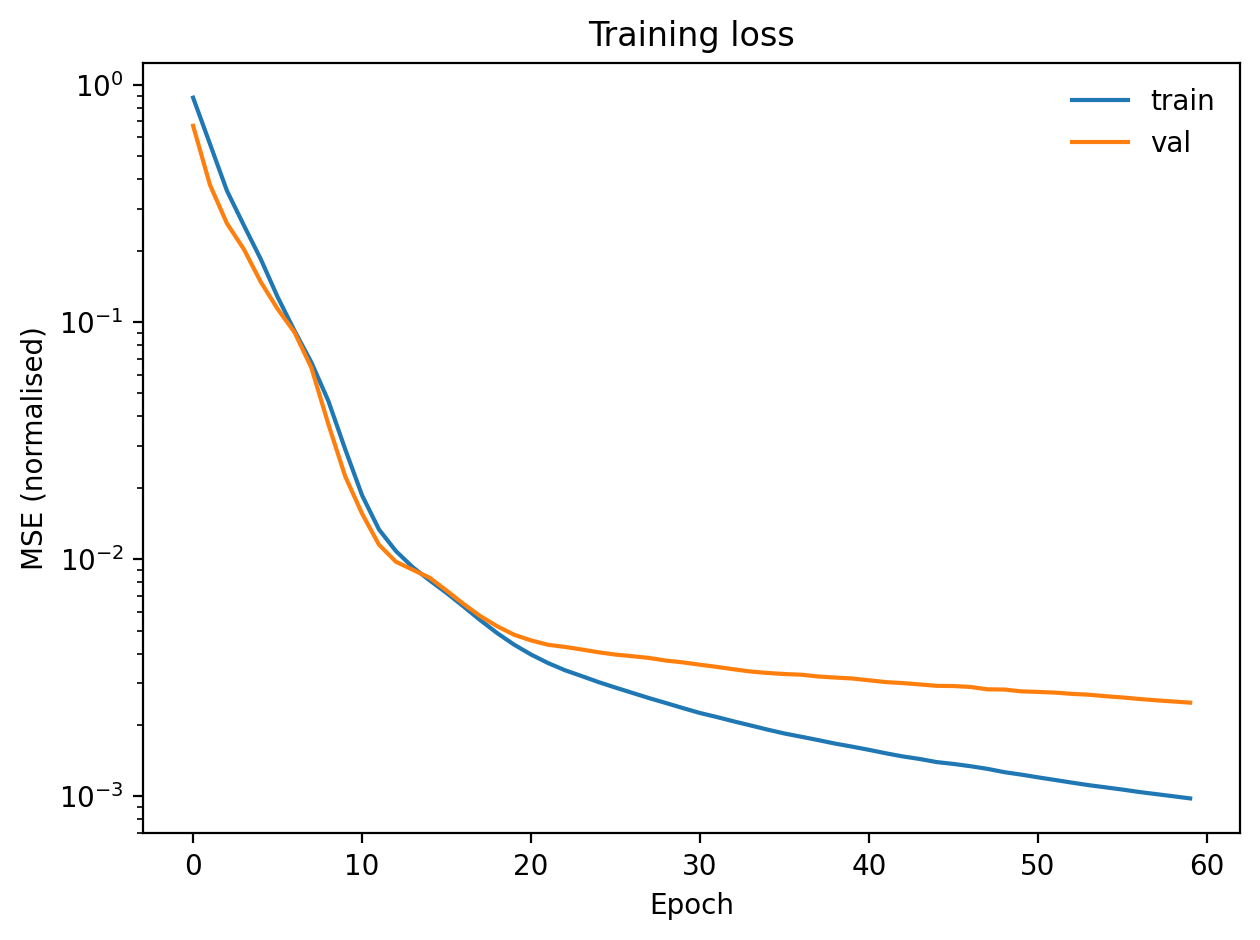

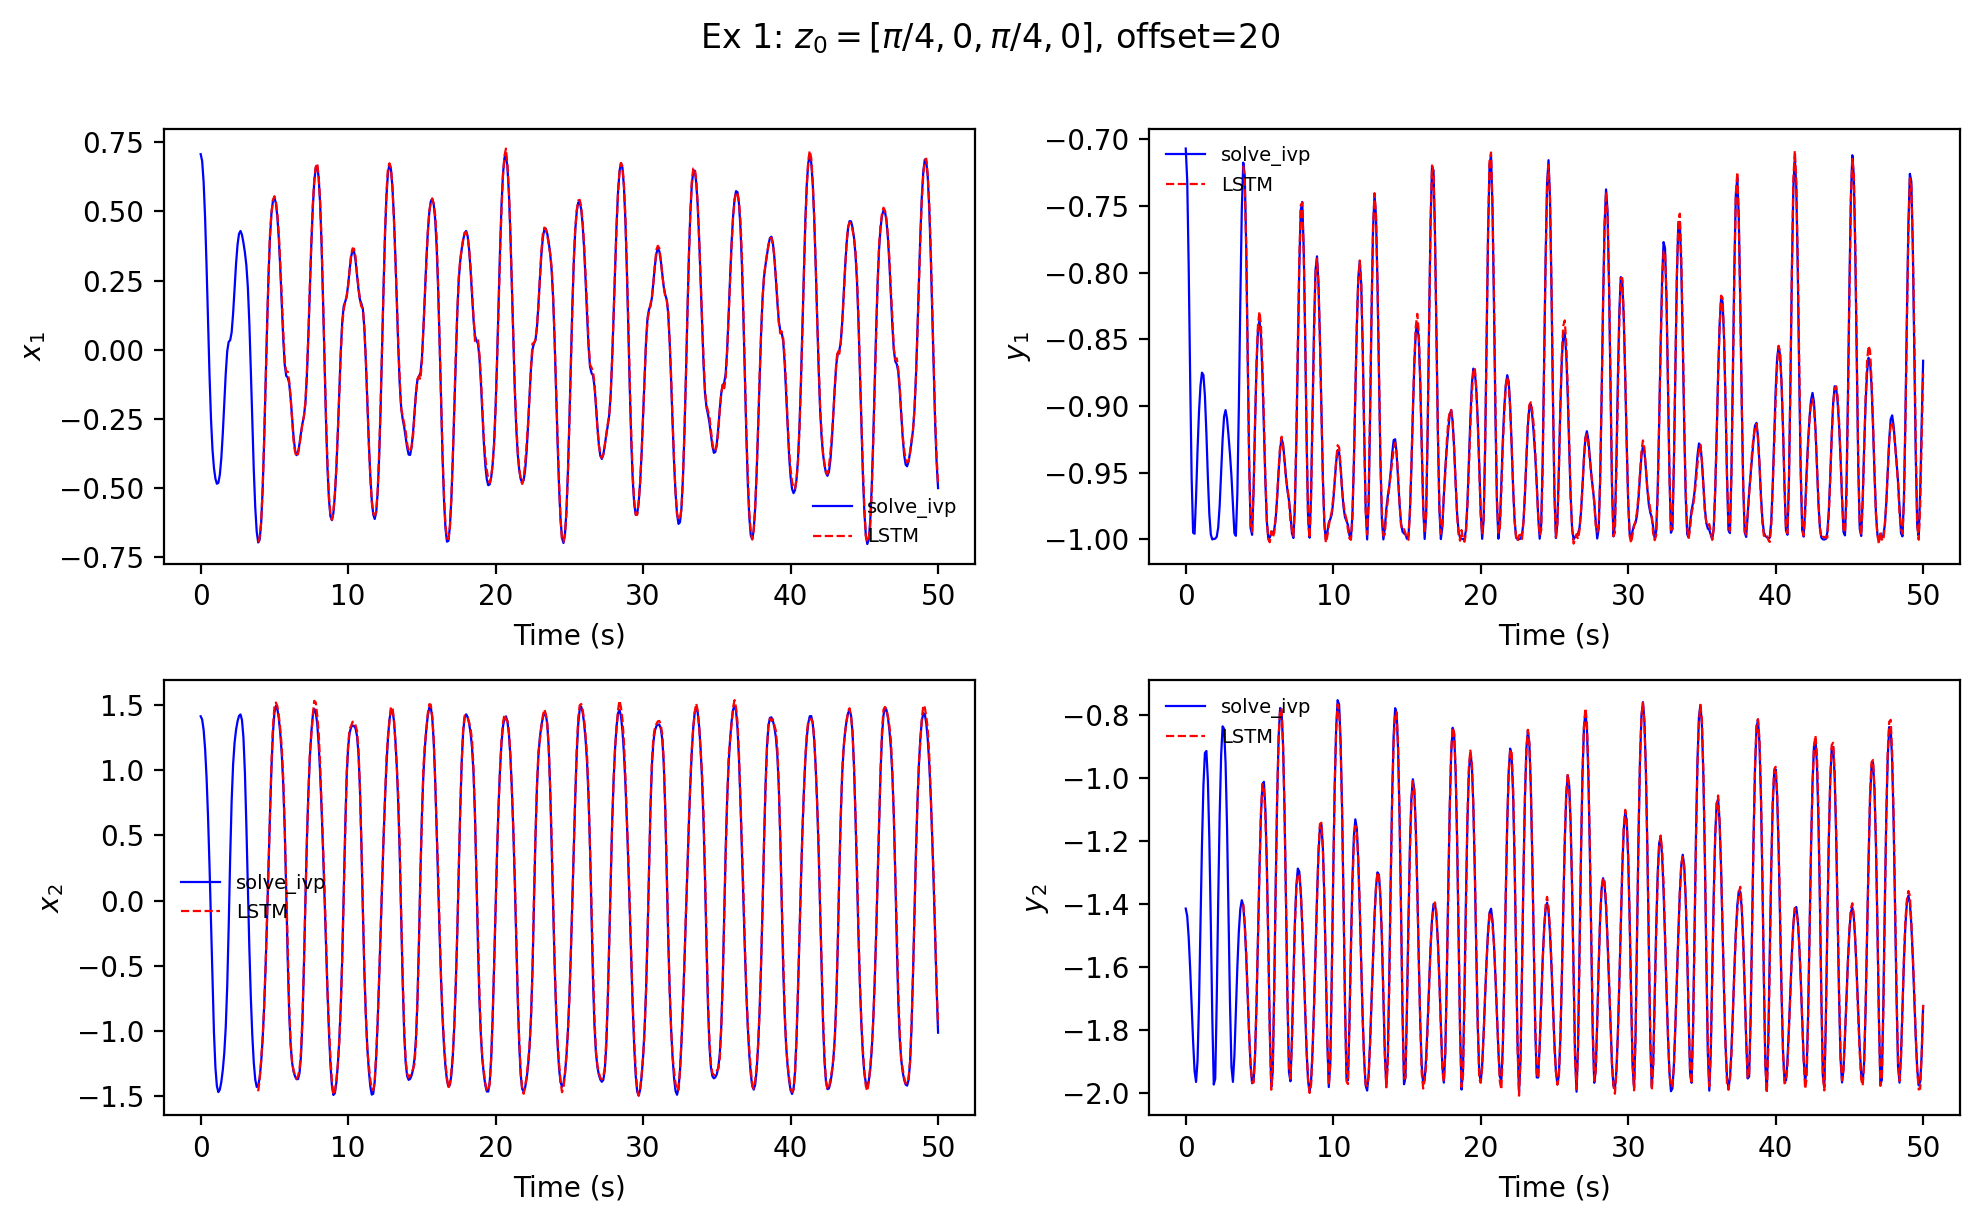

In [73]:
# set the standard initial condition
Z0_1 = [np.pi/4, 0, np.pi/4, 0]

# generate the corresponding standadrd physical data
t_s, cart_s = solve_pendulum(Z0_1)   # cart_s shape: (501, 4)

model_s, hist_s, pred_s, truth_s, idx_s, mean_s, std_s = run_pipeline(
    cart_s, WINDOW_SIZE, OFFSET, n_features=4
)

# Plot the training loss curve to check if the model converges normally
plot_loss(hist_s, title='Training loss')

# Physical time points corresponding to the prediction results
pred_t_s = t_s[idx_s]


plot_xy_vs_time(t_s, cart_s, pred_t_s, pred_s,
                title=r'Ex 1: $z_0=[\pi/4,0,\pi/4,0]$, offset=20')

Generating unseen physics data with z0 = [0.8853981633974483, 0, 0.7853981633974483, 0]...
Predicting unseen trajectory with the pre-trained model...
Exercise 2 Generalization MSE: 0.02829


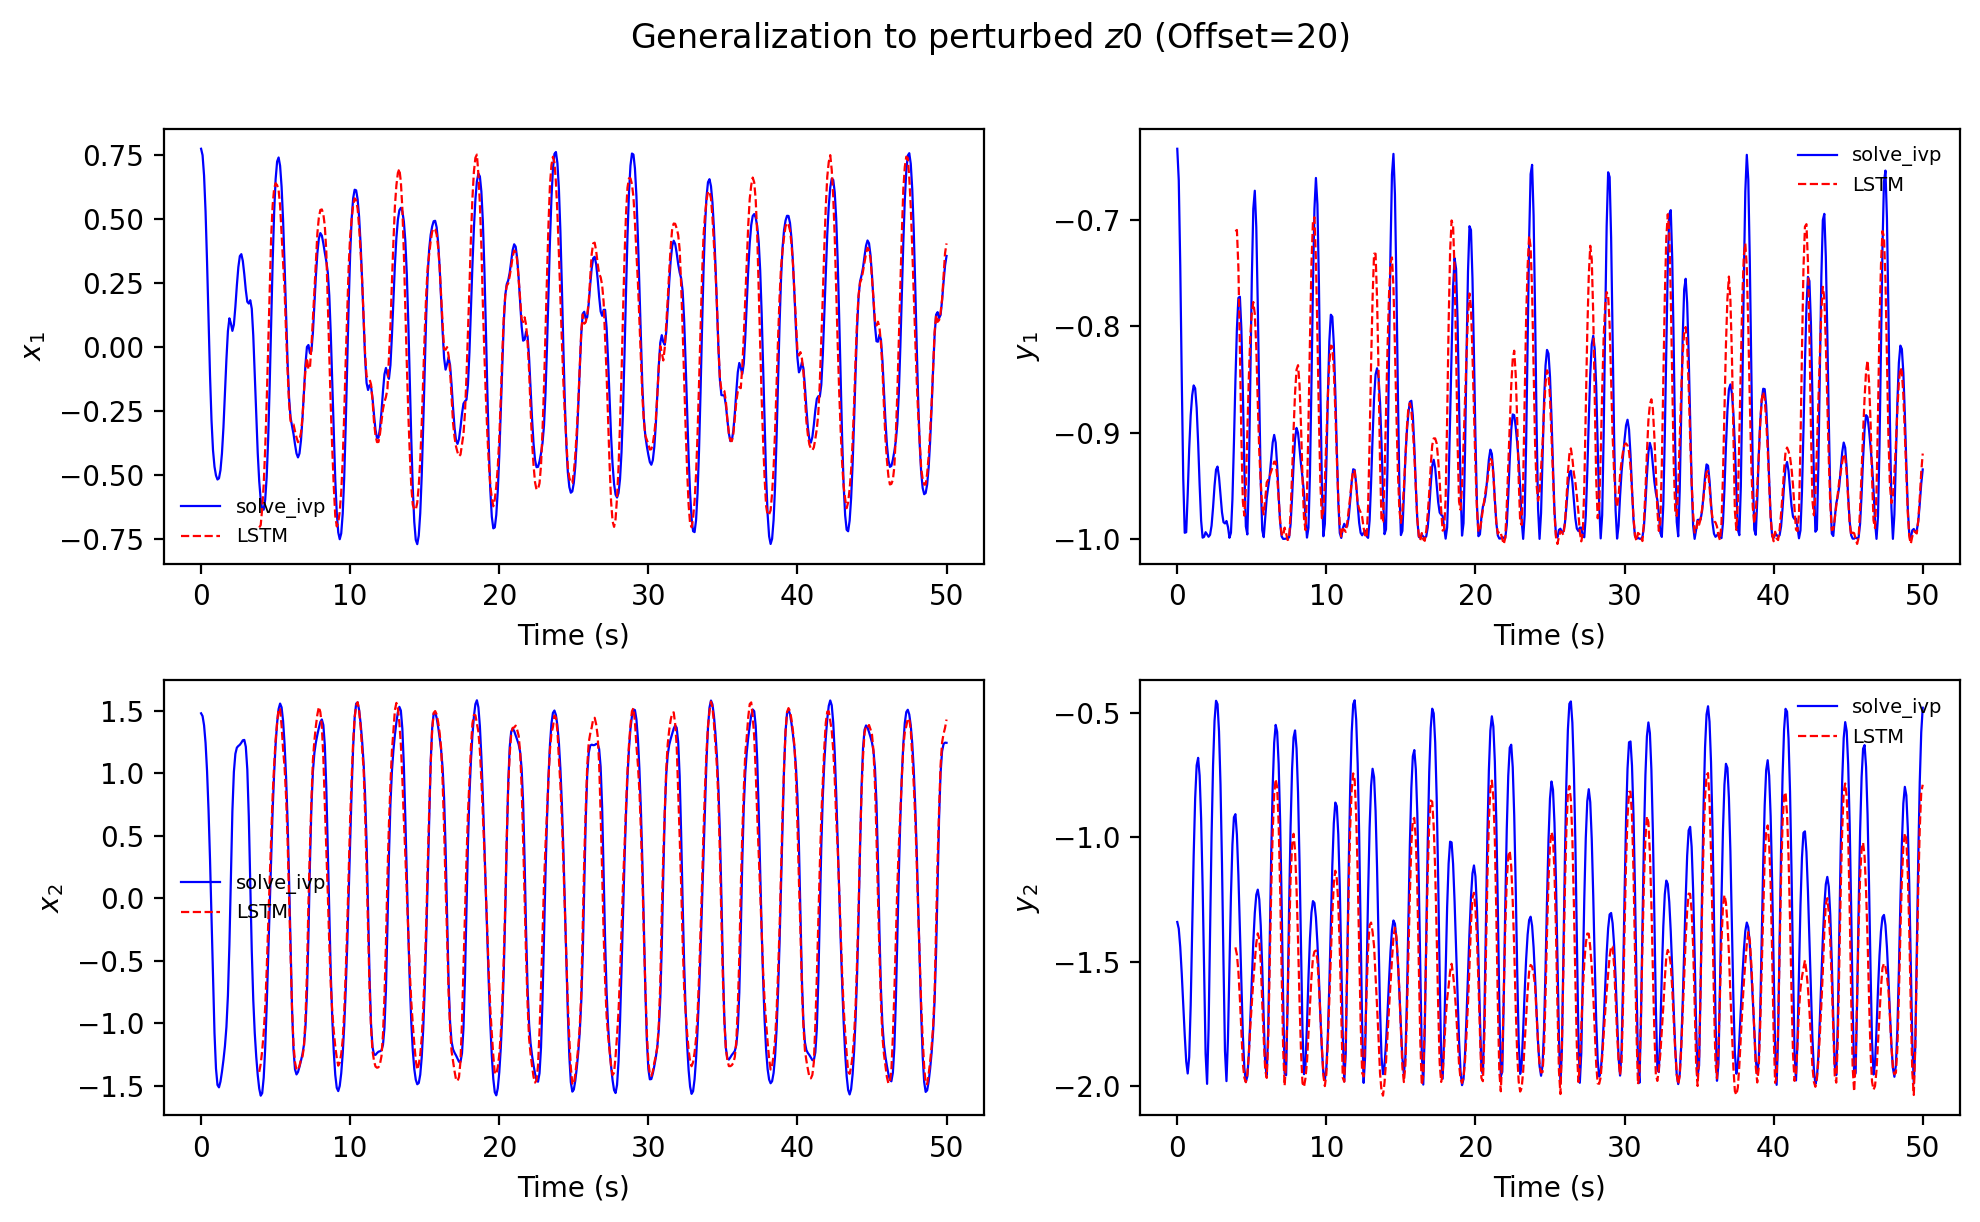

In [74]:
# Generalization to New Initial Conditions with pertubation

# Define a perturbed initial condition (+0.1 rad to the top angle)
z0_perturbed = [np.pi/4 + 0.1, 0, np.pi/4, 0]

print(f"Generating unseen physics data with z0 = {z0_perturbed}...")

# Generate new ground truth trajectory
t_new, cart_new = solve_pendulum(z0_perturbed, tmax=50, dt=0.1)

# Extract features and normalize using the ORIGINAL training statistics
data_new = cart_new[:, -4:]
data_new_norm = (data_new - mean_s) / std_s  # Reuse original mean and std

# Create sliding windows
X_new, y_new = make_windows(data_new_norm, WINDOW_SIZE, OFFSET)

print("Predicting unseen trajectory with the pre-trained model...")

# Predict using the pre-trained model (no fitting/training)
pred_new_norm = model_s.predict(X_new, verbose=0)

# Denormalize predictions and truth using original statistics
pred_new = denormalise(pred_new_norm, mean_s, std_s)
truth_new = denormalise(y_new, mean_s, std_s)

# Calculate and print MSE
mse_new = np.mean((pred_new - truth_new) ** 2)
print(f"Exercise 2 Generalization MSE: {mse_new:.5f}")

# Align time axis and visualize results
pred_t_idx_new = np.arange(WINDOW_SIZE + OFFSET - 1,
                           WINDOW_SIZE + OFFSET - 1 + len(pred_new))
pred_time_axis_new = t_new[pred_t_idx_new]

plot_xy_vs_time(
    t_full=t_new,
    cart_truth=cart_new,
    pred_t=pred_time_axis_new,
    pred=pred_new,
    title=f'Generalization to perturbed $z0$ (Offset={OFFSET})'
)

Scanning offsets to find extrapolation limits: [20, 30, 40, 50, 60, 70, 80, 90, 100]
  offset= 20  MSE=0.00022
  offset= 30  MSE=0.00029
  offset= 40  MSE=0.00019
  offset= 50  MSE=0.00026
  offset= 60  MSE=0.00029
  offset= 70  MSE=0.00030
  offset= 80  MSE=0.00040
  offset= 90  MSE=0.00032
  offset=100  MSE=0.00036


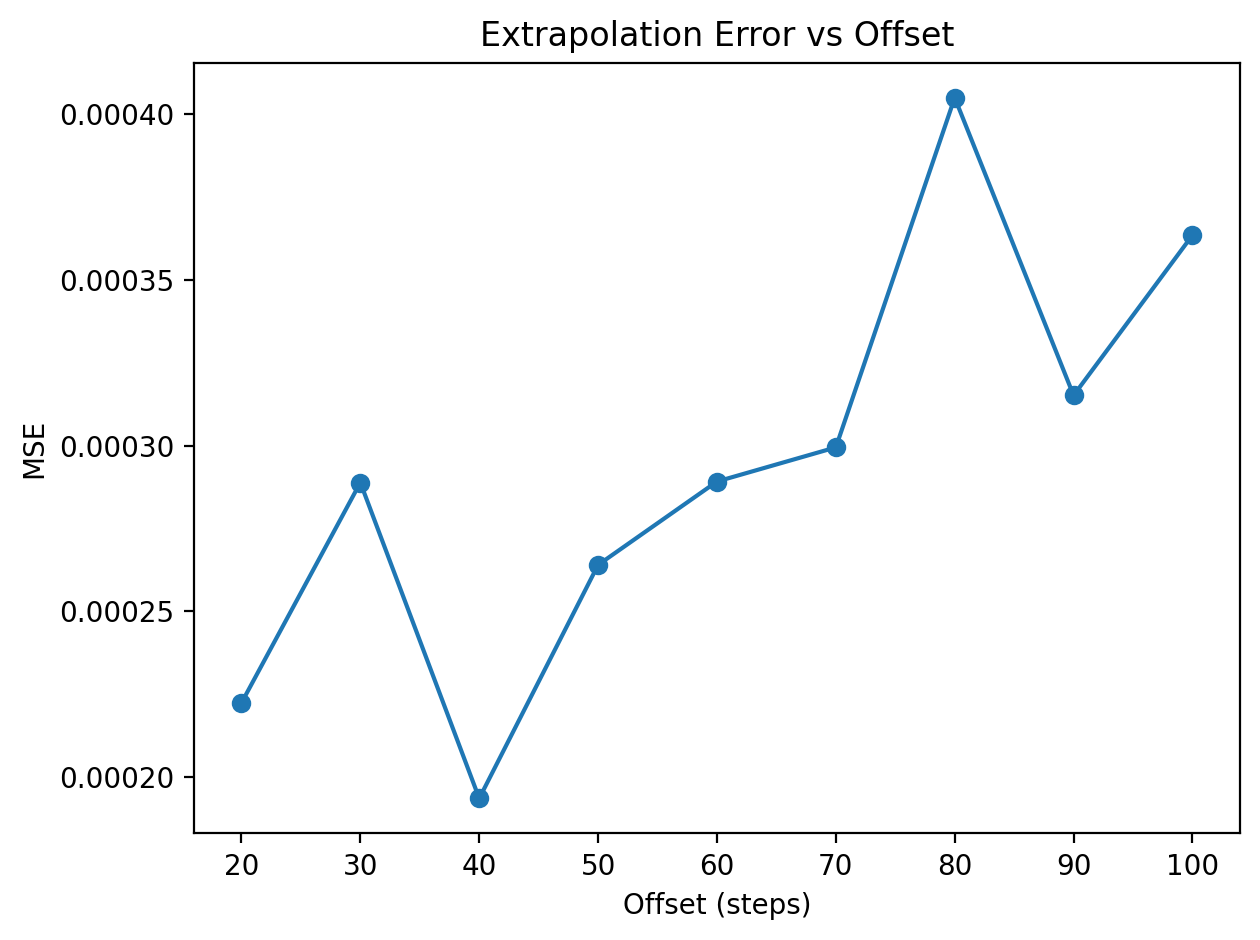

In [75]:
# Define the range of offsets to test (from 20*dt to 100*dt. Using a step of 10 to reduce total training time (e.g., 20, 30, 40... 100)
offset_list = list(range(20, 101, 10))

print(f"Scanning offsets to find extrapolation limits: {offset_list}")

# Train a new network for each offset and record the Mean Squared Error (MSE)
# using the stable initial condition data (cart_data_stable)
# n_features=4 means we are still predicting the full system (both masses)
mse_errors_stable = scan_offsets(
    cart_data=cart_s,
    window_size=WINDOW_SIZE,
    offsets=offset_list,
    n_features=4,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

# 3. Visualize how the prediction error grows as we look further into the future
plot_error_vs_offset(
    offsets=offset_list,
    errors=mse_errors_stable,
    title='Extrapolation Error vs Offset'
)

## Part 2

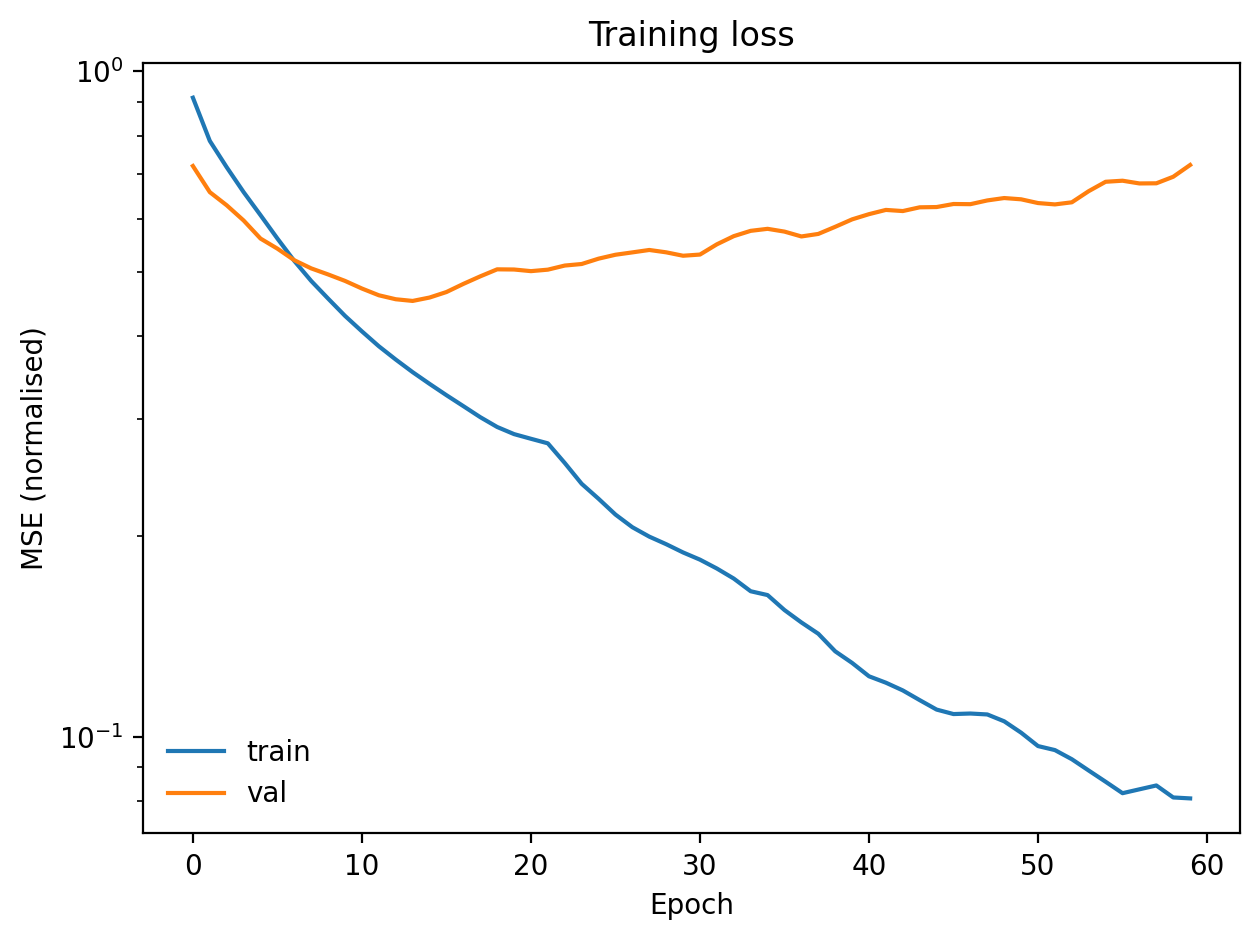

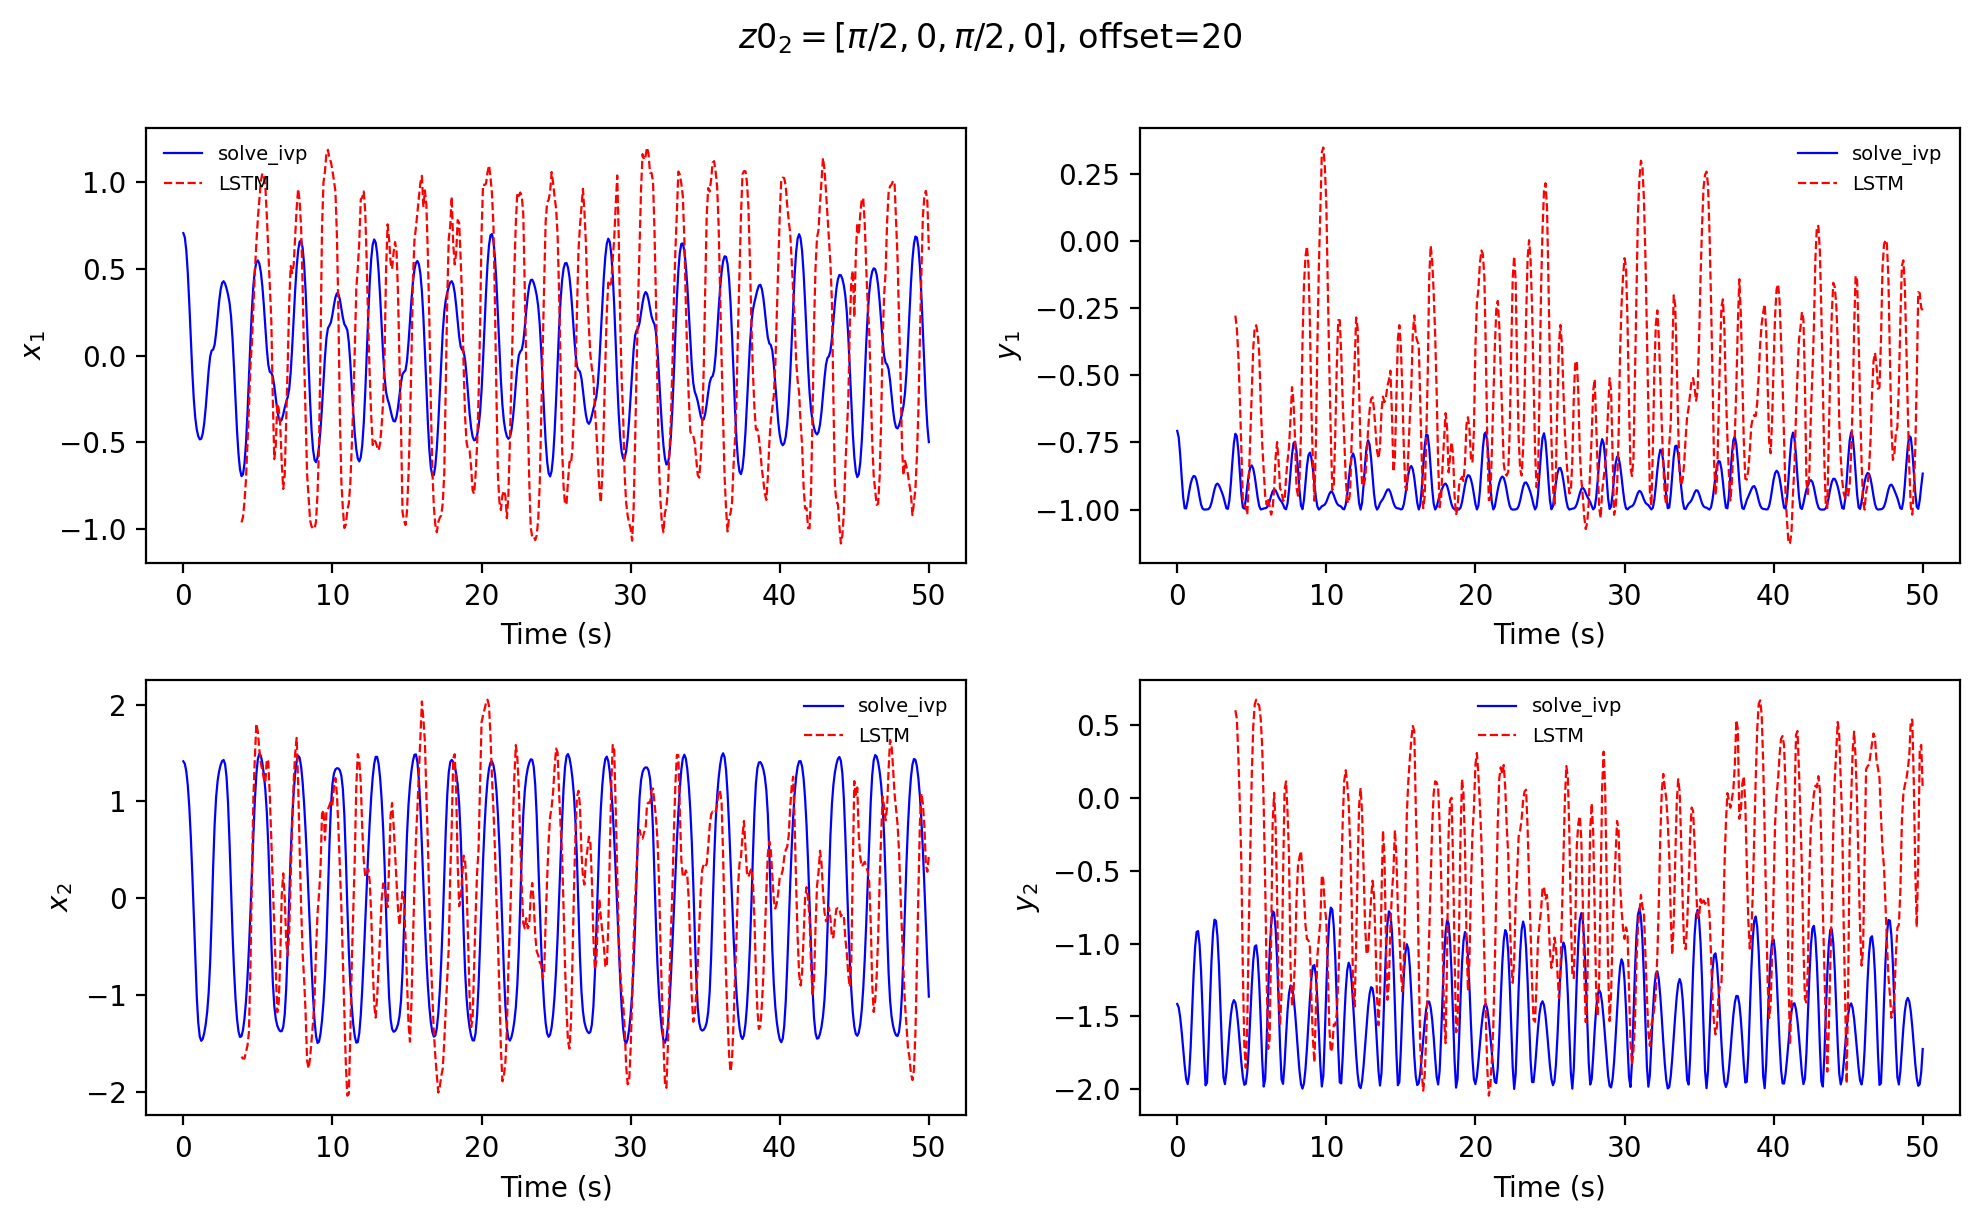

In [76]:
Z0_2 = [np.pi/2, 0, np.pi/2, 0]

t_s_2, cart_s_2 = solve_pendulum(Z0_2)   # cart_s shape: (501, 4)

model_s, hist_s, pred_s, truth_s, idx_s, mean_s, std_s = run_pipeline(
    cart_s_2, WINDOW_SIZE, OFFSET, n_features=4
)

plot_loss(hist_s, title='Training loss')

pred_t_s = t_s_2[idx_s]
plot_xy_vs_time(t_s, cart_s, pred_t_s, pred_s,
                title=r'$z0_2=[\pi/2,0,\pi/2,0]$, offset=20')


  offset= 20  MSE=0.03216
  offset= 30  MSE=0.04153
  offset= 40  MSE=0.04327
  offset= 50  MSE=0.04018
  offset= 60  MSE=0.06804
  offset= 70  MSE=0.05419
  offset= 80  MSE=0.05161
  offset= 90  MSE=0.06008
  offset=100  MSE=0.06179


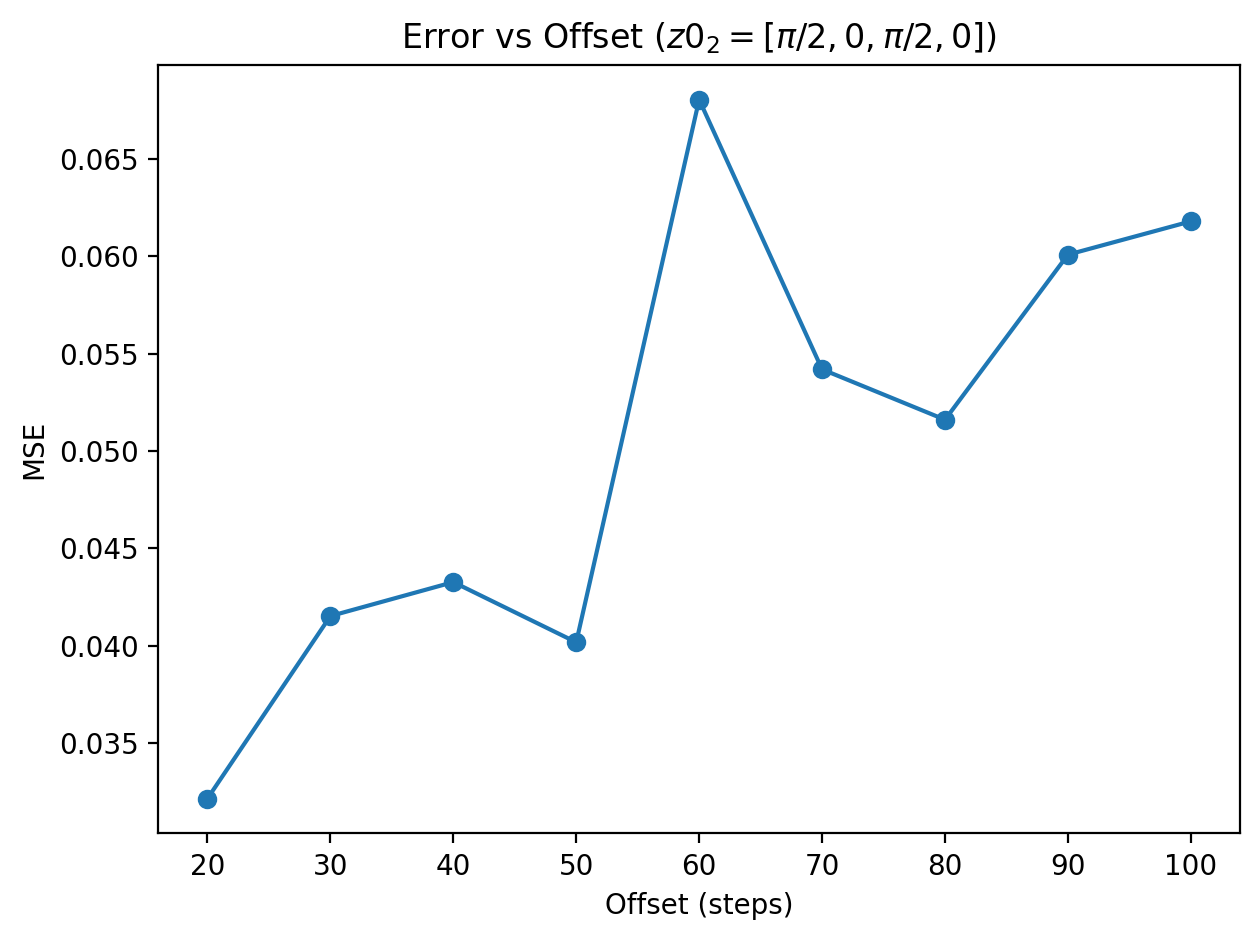

In [77]:
# Extrapolation Limit for Chaos

# Define the range of offsets (from 20 to 100)
offsets_s = list(range(20, 101, 10))

# Train models for each offset using the chaotic data (cart_s)
errors_s = scan_offsets(
    cart_data=cart_s_2,
    window_size=WINDOW_SIZE,
    offsets=offsets_s,
    n_features=4,           # Still predicting all 4 coordinates
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

# Visualize the MSE growth as prediction horizon increases
plot_error_vs_offset(
    offsets=offsets_s,
    errors=errors_s,
    title=r'Error vs Offset ($z0_2=[\pi/2,0,\pi/2,0]$)'
)

## Part 3

Running Ex 5: Stable Conditions (Training on m2 only)...


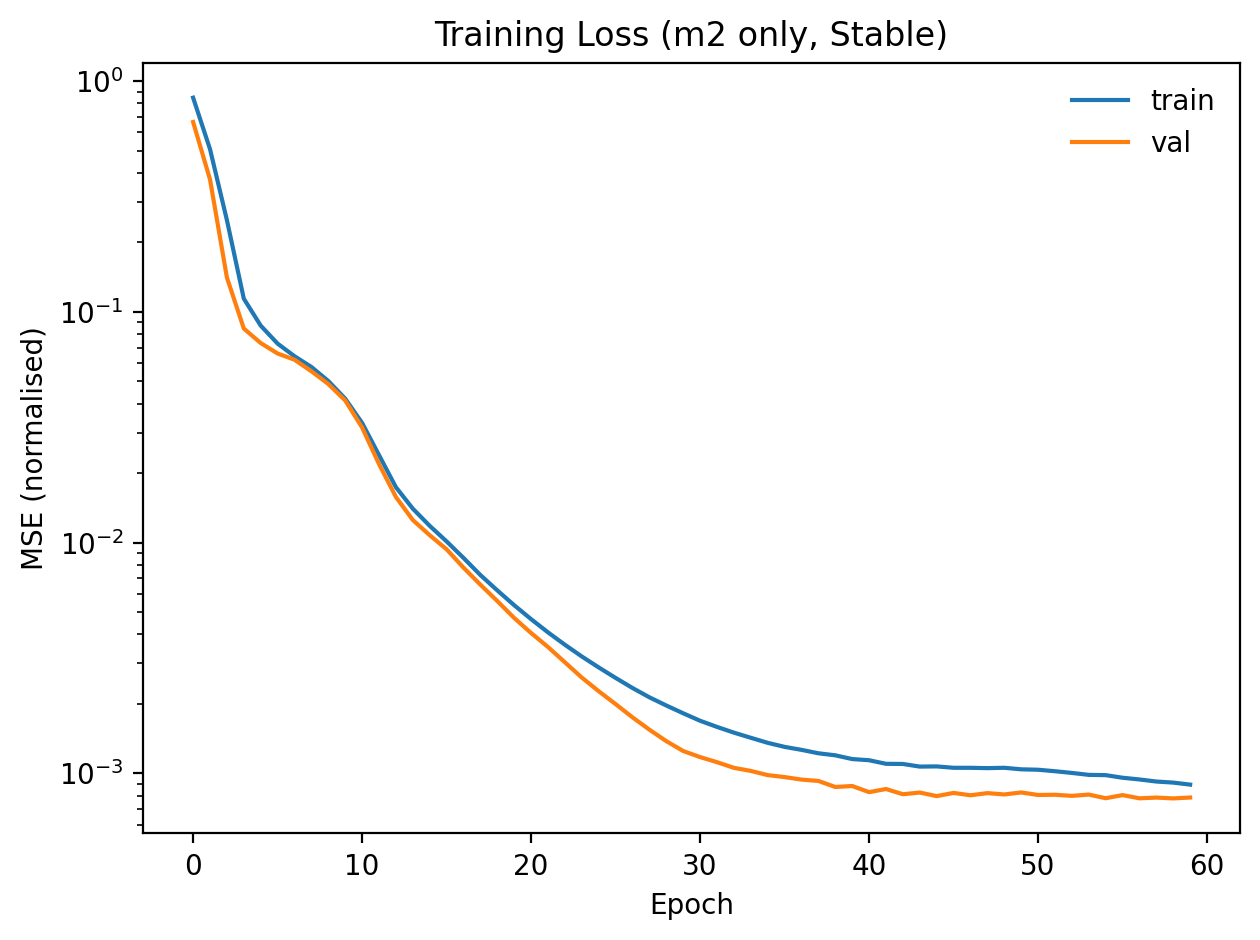

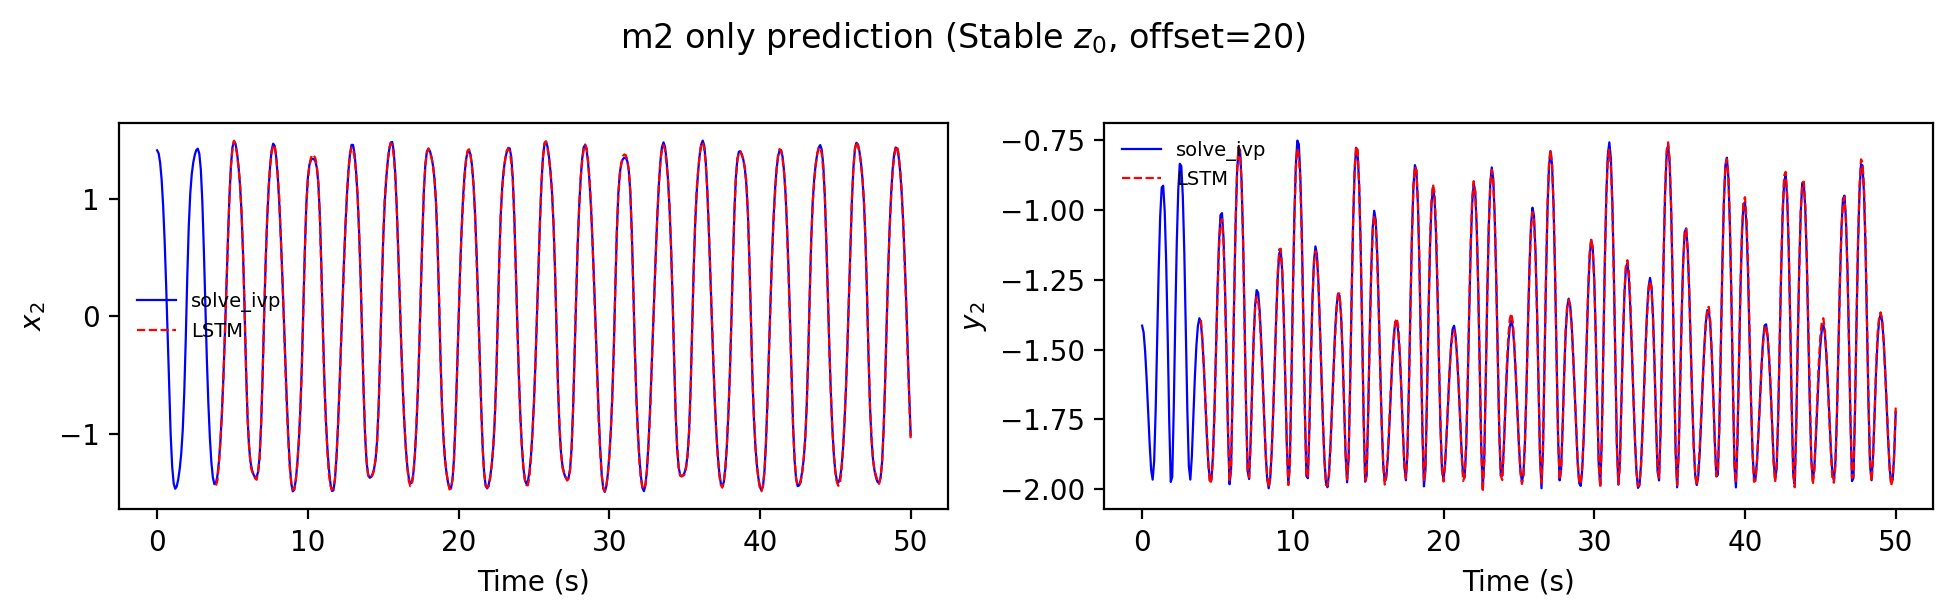

In [78]:
print("Running Ex 5: Stable Conditions (Training on m2 only)...")

# Train model for offset=20 using only 2 features (x2, y2)
model_m2_stable, hist_m2_stable, pred_m2_stable, truth_m2_stable, idx_m2_stable, mean_m2_s, std_m2_s = run_pipeline(
    cart_data=cart_s,
    window_size=WINDOW_SIZE,
    offset=OFFSET,
    n_features=2   # Network only sees x2 and y2
)

# Visualize basic prediction performance for m2
plot_loss(hist_m2_stable, title='Training Loss (m2 only, Stable)')
plot_xy_vs_time(
    t_full=t_s,
    cart_truth=cart_s,
    pred_t=t_s[idx_m2_stable],
    pred=pred_m2_stable,
    title=r'm2 only prediction (Stable $z_0$, offset=20)'
)

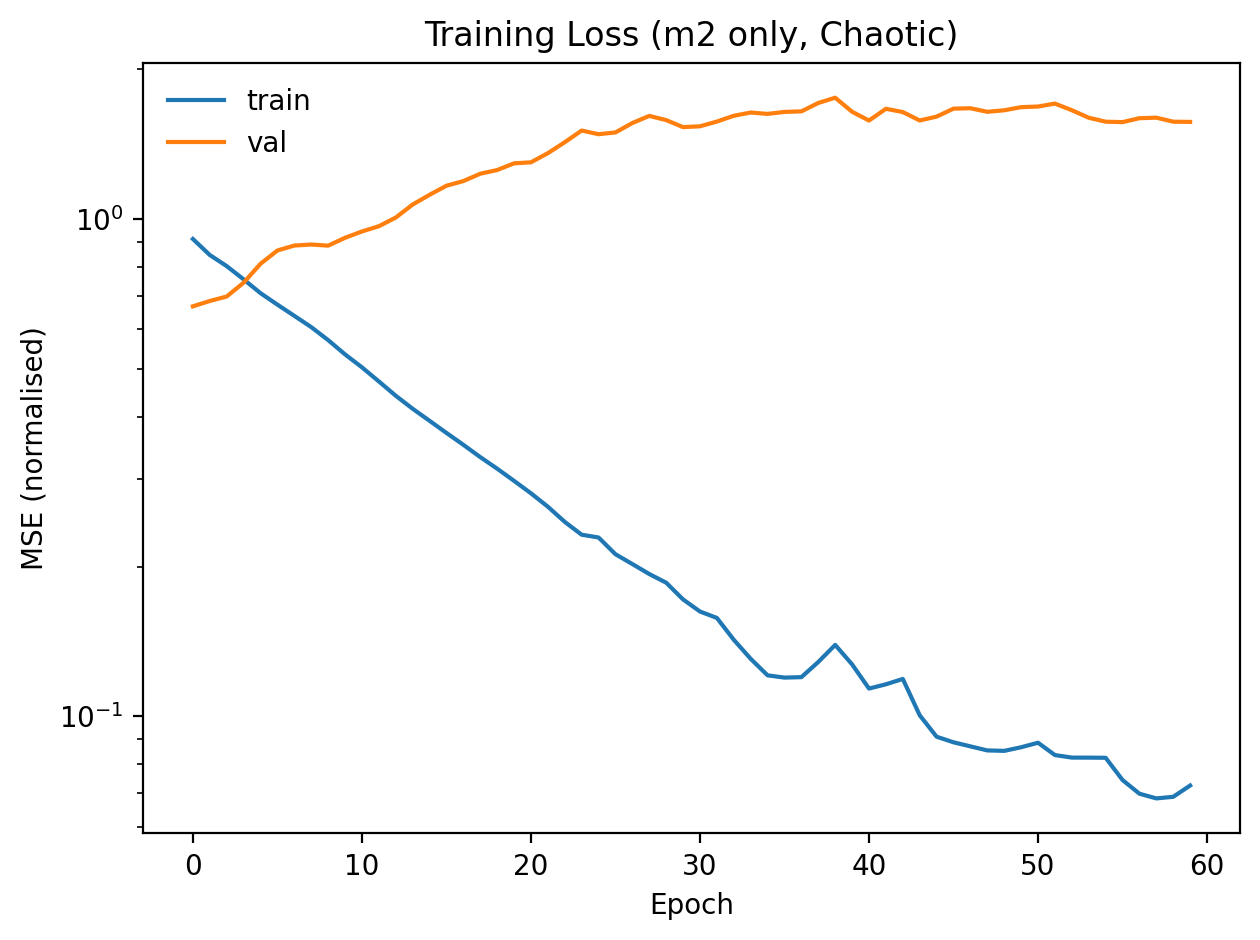

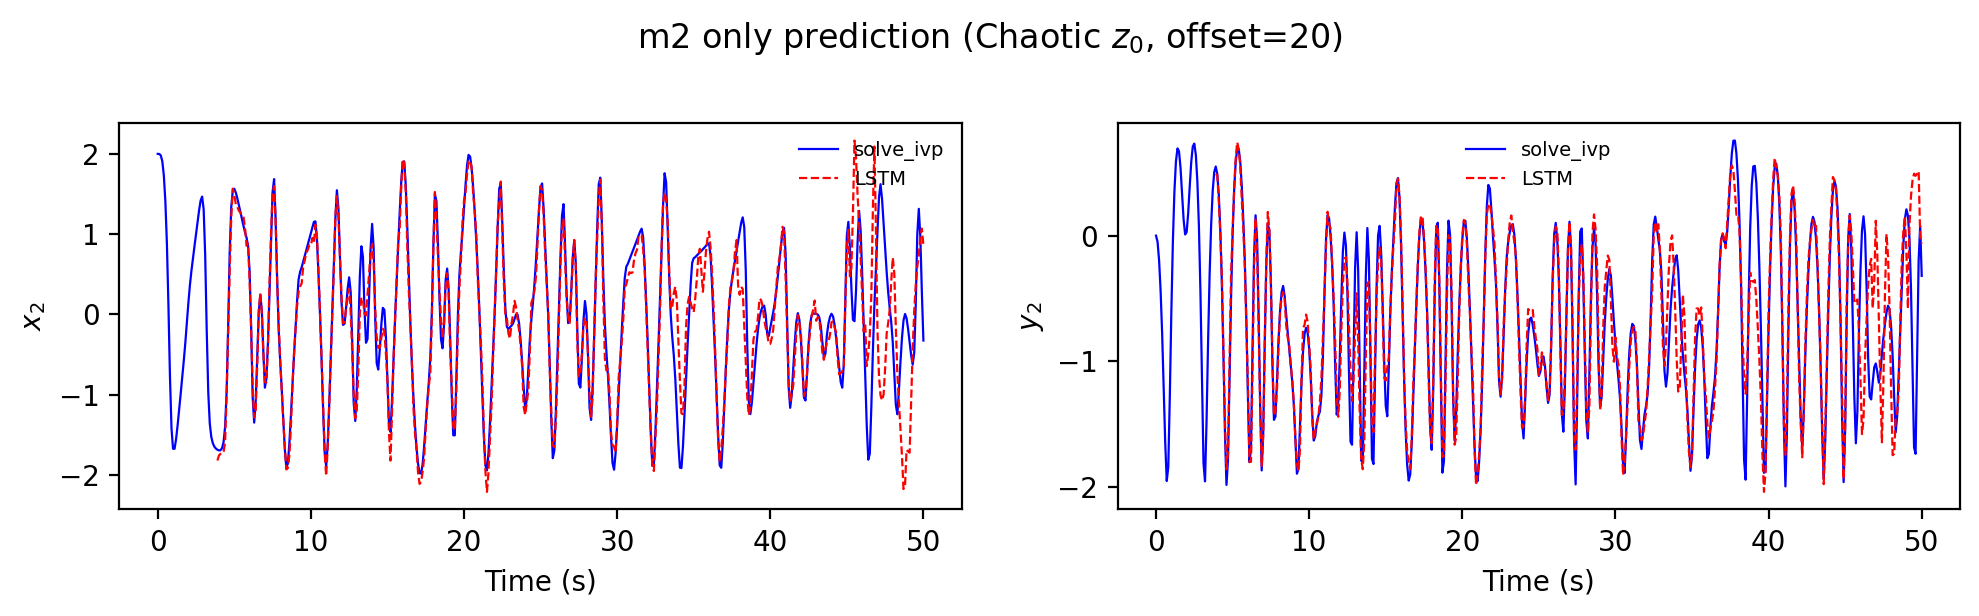

In [79]:
# Chaotic Initial Conditions (m2 only)

# Train model for offset=20 using only 2 features (x2, y2)
model_m2_chaotic, hist_m2_chaotic, pred_m2_chaotic, truth_m2_chaotic, idx_m2_chaotic, mean_m2_c, std_m2_c = run_pipeline(
    cart_data=cart_s_2,
    window_size=WINDOW_SIZE,
    offset=OFFSET,
    n_features=2
)

# Visualize basic prediction performance for m2 (Chaotic)
plot_loss(hist_m2_chaotic, title='Training Loss (m2 only, Chaotic)')

# use time array of chaotic condition
pred_t_m2_chaotic = t_s[idx_m2_chaotic]

plot_xy_vs_time(
    t_full=t_s_2,
    cart_truth=cart_s_2,
    pred_t=pred_t_m2_chaotic,
    pred=pred_m2_chaotic,
    title=r'm2 only prediction (Chaotic $z_0$, offset=20)'
)


Scanning offsets for Stable Conditions (m2 only)...
  offset= 20  MSE=0.00019
  offset= 30  MSE=0.00031
  offset= 40  MSE=0.00043
  offset= 50  MSE=0.00045
  offset= 60  MSE=0.00047
  offset= 70  MSE=0.00052
  offset= 80  MSE=0.00049
  offset= 90  MSE=0.00046
  offset=100  MSE=0.00052

Scanning offsets for Chaotic Conditions (m2 only)...
  offset= 20  MSE=0.04638
  offset= 30  MSE=0.06065
  offset= 40  MSE=0.06412
  offset= 50  MSE=0.09233
  offset= 60  MSE=0.10770
  offset= 70  MSE=0.06783
  offset= 80  MSE=0.09339
  offset= 90  MSE=0.12613
  offset=100  MSE=0.09621


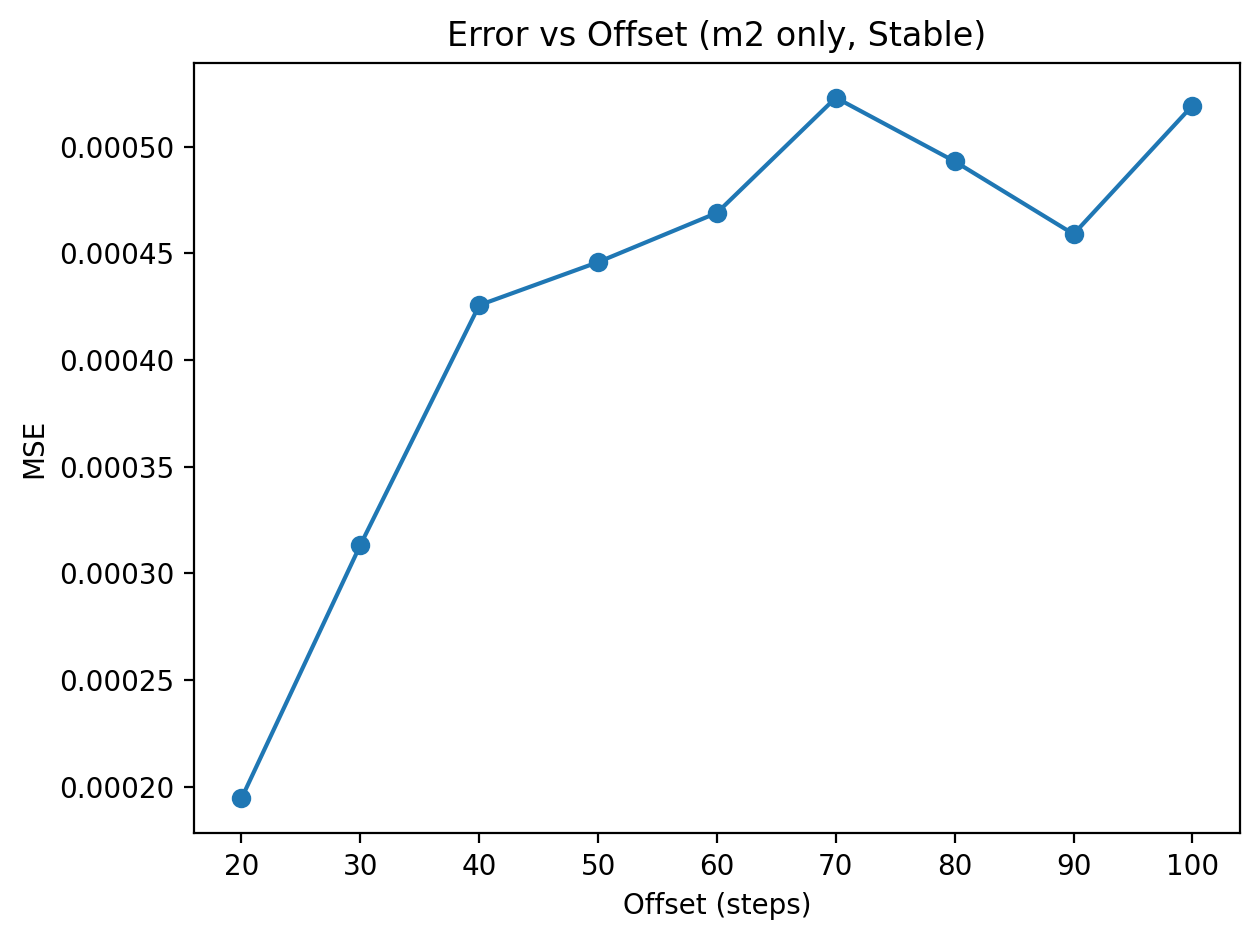

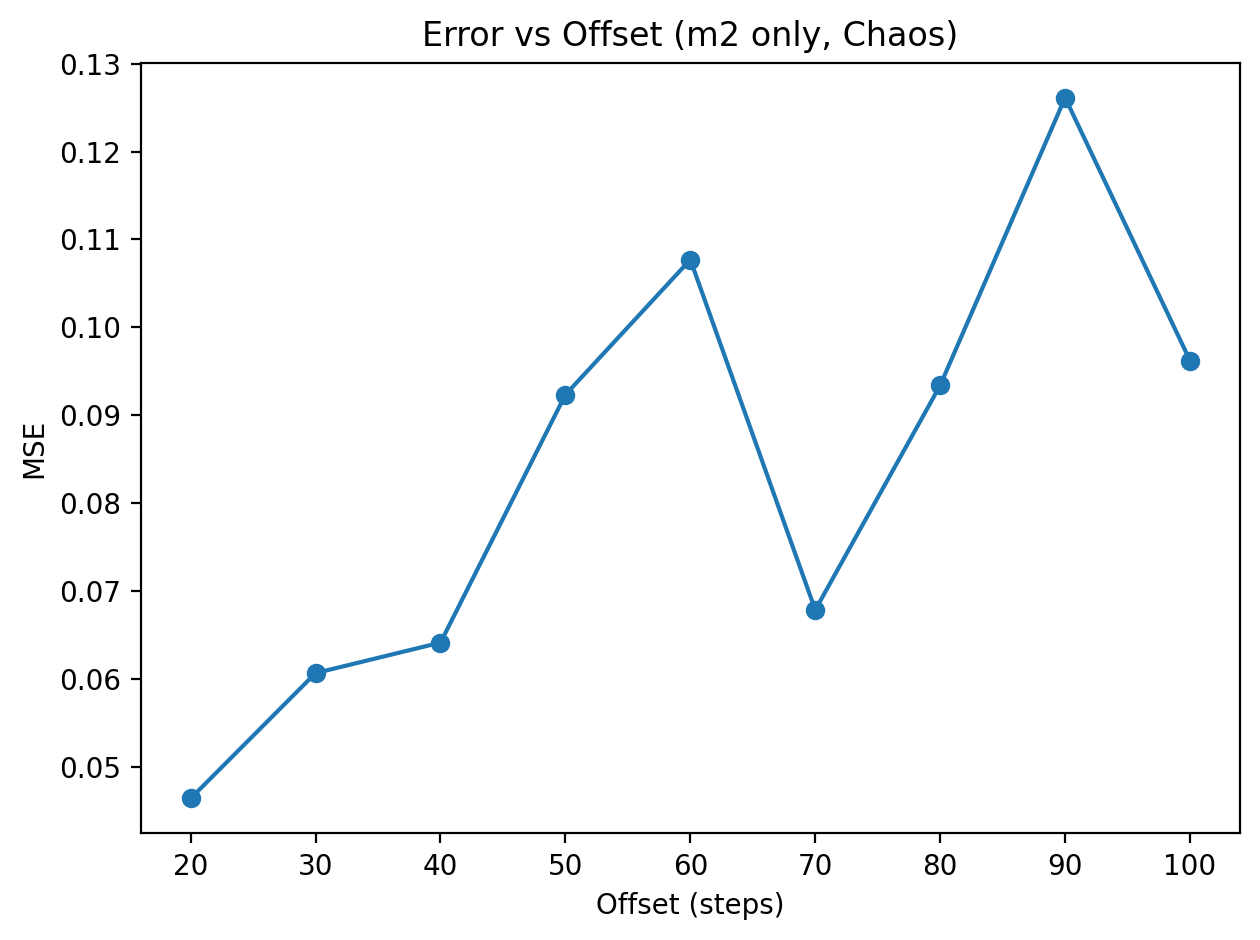

In [80]:
# Extrapolation Scan for both Stable and Chaotic (m2 only) ---
offsets_list = list(range(20, 101, 10))

# Scan offsets for stable condition (m2 only)
print("\nScanning offsets for Stable Conditions (m2 only)...")
errors_m2_stable = scan_offsets(
    cart_data=cart_s,
    window_size=WINDOW_SIZE,
    offsets=offsets_list,
    n_features=2
)

# Scan offsets for chaotic condition (m2 only)
print("\nScanning offsets for Chaotic Conditions (m2 only)...")
errors_m2_chaotic = scan_offsets(
    cart_data=cart_s_2,
    window_size=WINDOW_SIZE,
    offsets=offsets_list,
    n_features=2
)

# Visualize the error growth
plot_error_vs_offset(offsets_list, errors_m2_stable, title='Error vs Offset (m2 only, Stable)')
plot_error_vs_offset(offsets_list, errors_m2_chaotic, title='Error vs Offset (m2 only, Chaos)')

## Discussion
This coursework investigated the time-series forecasting capabilities of a Long Short-Term Memory (LSTM) network on a double pendulum system under varying physical and observational conditions. For the stable initial condition ($z_0=[\pi/4,0,\pi/4,0]$), the model exhibited exceptional predictive accuracy, maintaining a low Mean Squared Error (MSE) over extended extrapolation horizons.

Furthermore, the network demonstrated robust generalization when tested on a perturbed, unseen initial state. This indicates that the LSTM successfully approximated the underlying local Lagrangian dynamics rather than simply memorizing the training trajectory.

However, tests on the chaotic state ($z_0=[\pi/2,0,\pi/2,0]$) revealed the fundamental physical limits of forecasting highly non-linear systems. As the prediction offset increased, the error grew exponentially, perfectly illustrating the system's extreme sensitivity to initial conditions, before eventually saturating at the physical spatial boundaries of the pendulum.

Finally, the blind test with incomplete information highlighted the critical role of state observability. When the network was trained solely on the lower mass ($m_2$) while the upper mass ($m_1$) was hidden, predictive performance degraded drastically, failing completely in the chaotic regime. This powerfully demonstrates that when using deep learning to model complex, coupled dynamical systems, acquiring complete system state features is an absolute prerequisite for accurate long-term forecasting.